In [1]:
import matplotlib.pyplot as plt
from oqtant.schemas.quantum_matter import QuantumMatterFactory
from matplotlib import pyplot as plt
import numpy as np
from scipy.ndimage import rotate
from scipy.optimize import curve_fit
from copy import deepcopy

qmf = QuantumMatterFactory()
qmf.get_login()

Auth(children=(HBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x12\x00\x00\x00\xc…

In [2]:
qmf.get_client()

Job Limits:
╒═══════════════╤═══════════════════╤════════════════════╤════════════════════╕
│   Daily Limit │   Daily Remaining │   Standard Credits │   Priority Credits │
╞═══════════════╪═══════════════════╪════════════════════╪════════════════════╡
│            20 │                 8 │                 72 │                  0 │
╘═══════════════╧═══════════════════╧════════════════════╧════════════════════╛


In [3]:
base_filename = "Data/NoPatternExpt_tof__rep_"
num_runs = 3

no_pattern = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

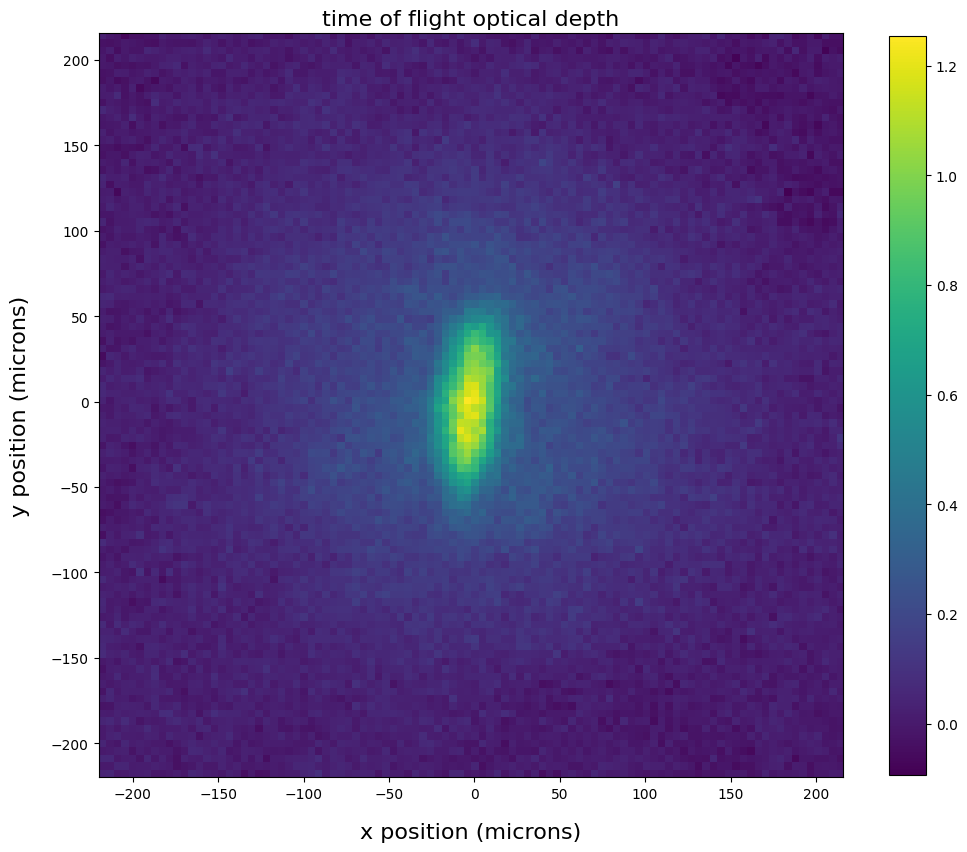

In [4]:
no_pattern[0].output.plot_tof()

In [5]:
base_filename = "Data/LongOnlyExpt_tof__rep_"
num_runs = 3

long_only = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

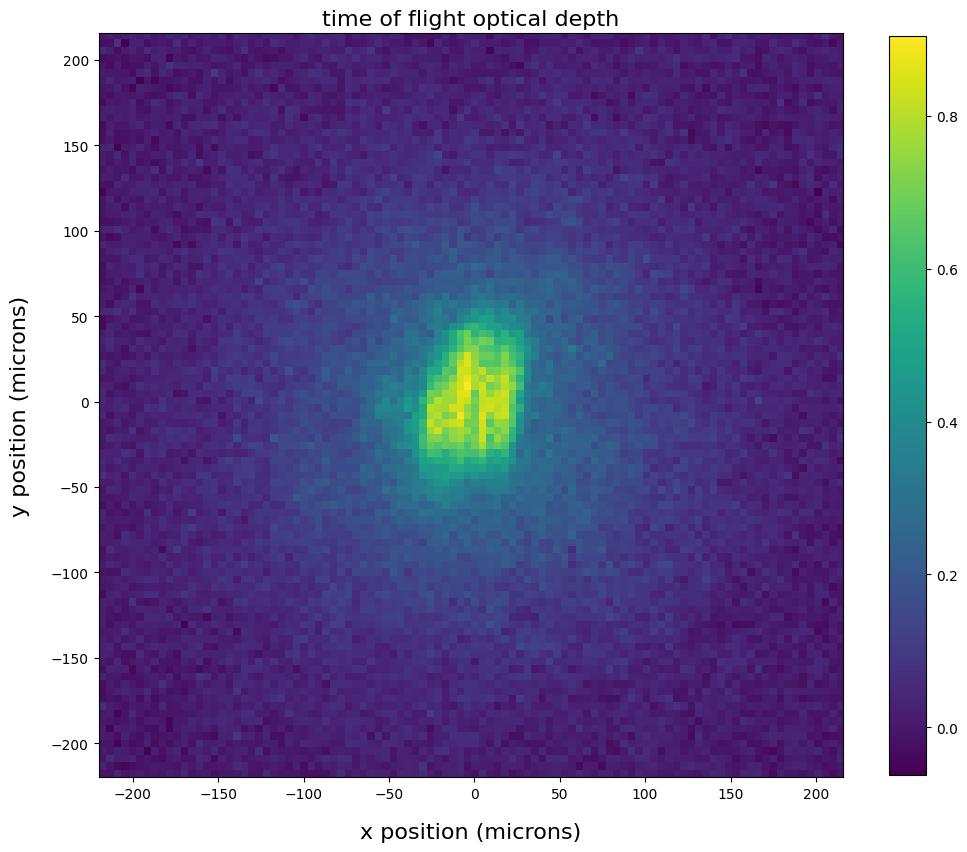

In [6]:
long_only[0].output.plot_tof()

In [7]:
base_filename = "Data/ShortOnlyExpt_tof__rep_"
num_runs = 3

short_only = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

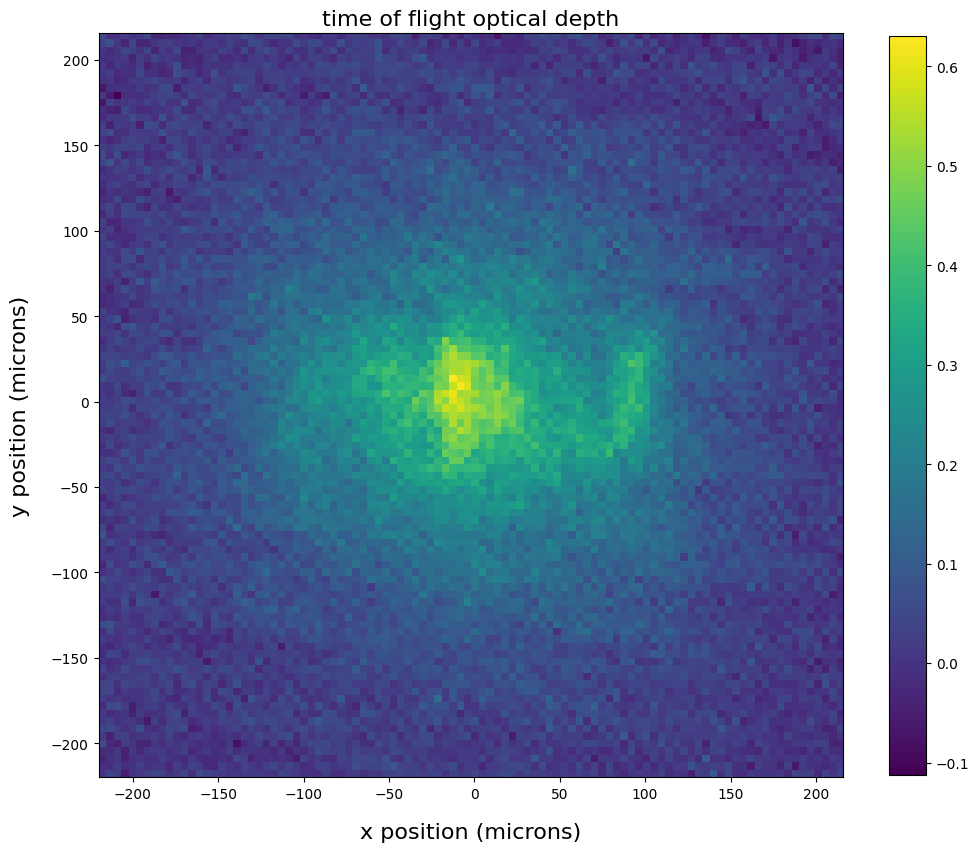

In [8]:
short_only[0].output.plot_tof()

In [10]:
base_filename = "Data/SuperlatticeExpt_tof__rep_"
num_runs = 3

superlattice = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

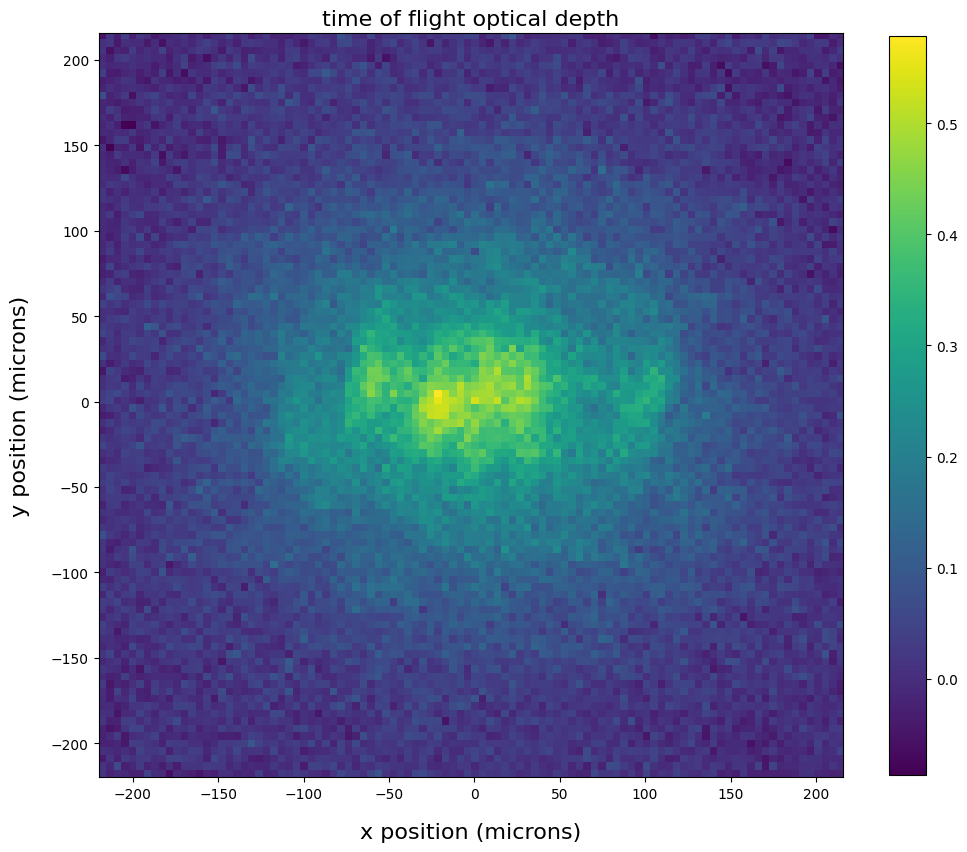

In [11]:
superlattice[2].output.plot_tof()

In [12]:
def averageMatterImages(matters, imaging):
    rows = matters[0].output.tof_image.rows
    columns = matters[0].output.tof_image.columns
    pixcal = matters[0].output.get_image_pixcal(image=imaging)
    avg_pixels = np.zeros((rows, columns))
    avg_slice = np.zeros(columns)
    
    for matter in matters:
        avg_pixels += matter.output.get_image_data(image=imaging)
        avg_slice += matter.output.get_image_data(image=imaging)[int(rows / 2)]
        
    num_runs = len(matters)
    avg_pixels /= num_runs
    avg_slice /= num_runs
    
    x_pos = np.arange(-columns / 2 * pixcal, columns / 2 * pixcal, pixcal)
    y_pos = np.arange(-rows / 2 * pixcal, rows / 2 * pixcal, pixcal)

    return avg_pixels, avg_slice, x_pos, y_pos

In [13]:
def plotAveragedImages(pixels, slices, xpos, ypos, title):
    fig, axs = plt.subplots(nrows=2, sharex=True)
    fig.suptitle(title)
    im = axs[0].imshow(pixels,
                       extent=[xpos[0], xpos[-1], 
                               ypos[0], ypos[-1]],
                      )
    cbaxes = fig.add_axes([0.15, 0.6, 0.15, 0.02])
    cb = plt.colorbar(im, cax=cbaxes, ticks=[0.0, 1], orientation="horizontal")
    cbaxes.tick_params(color="w", labelcolor="w")
    
    axs[1].plot(xpos, slices, label="Slice @ Y=0")
    axs[1].set_ylabel("Optical Depth")
    axs[1].set_yticks([0, 0.5, 1])
    axs[1].set_xlabel("X position ($\mu$m)")
    axs[1].legend()
    axs[0].set_ylabel("Y position ($\mu$m)")
    plt.subplots_adjust(hspace=0)
    plt.show()

In [14]:
npx, ns, nx, ny = averageMatterImages(no_pattern, "TIME_OF_FLIGHT")

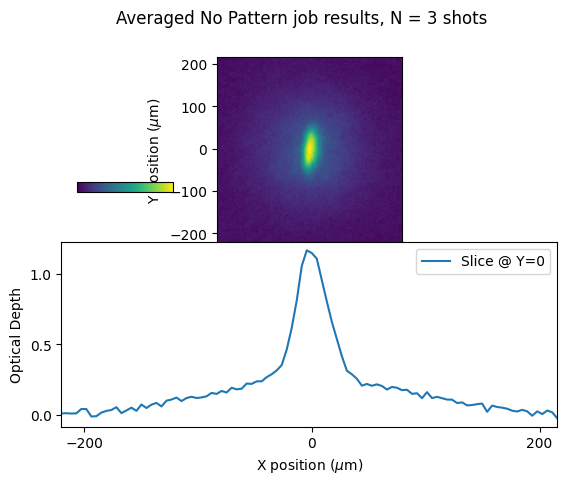

In [15]:
plotAveragedImages(npx, ns, nx, ny, "Averaged No Pattern job results, N = 3 shots")

In [16]:
lpx, ls, lx, ly = averageMatterImages(long_only, "TIME_OF_FLIGHT")

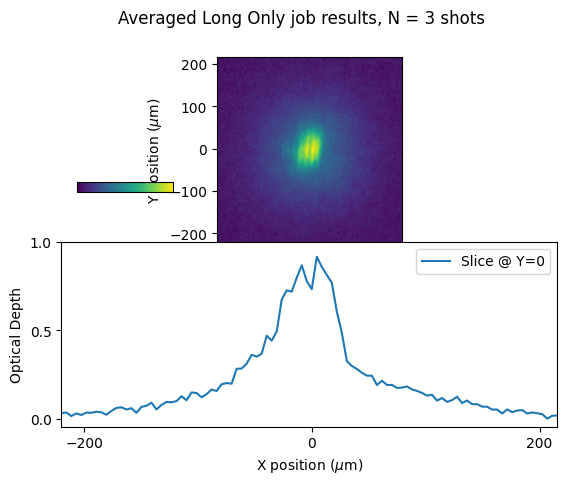

In [17]:
plotAveragedImages(lpx, ls, lx, ly, "Averaged Long Only job results, N = 3 shots")

In [18]:
spx, ss, sx, sy = averageMatterImages(short_only, "TIME_OF_FLIGHT")

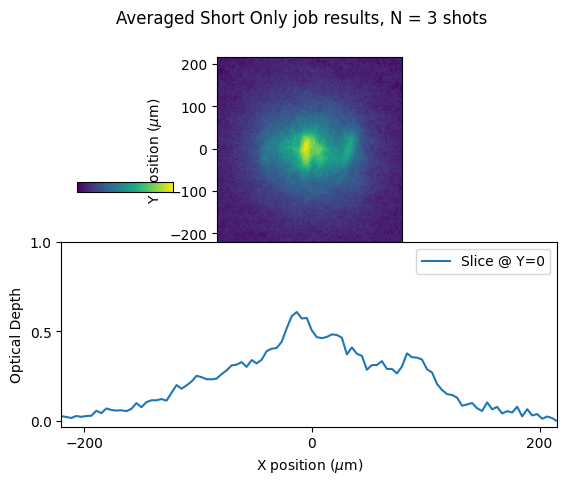

In [19]:
plotAveragedImages(spx, ss, sx, sy, "Averaged Short Only job results, N = 3 shots")

In [20]:
sspx, sss, ssx, ssy = averageMatterImages(superlattice, "TIME_OF_FLIGHT")

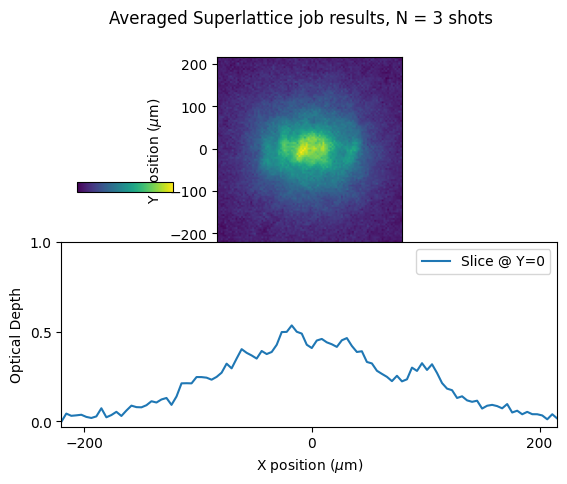

In [21]:
plotAveragedImages(sspx, sss, ssx, ssy, "Averaged Superlattice job results, N = 3 shots")

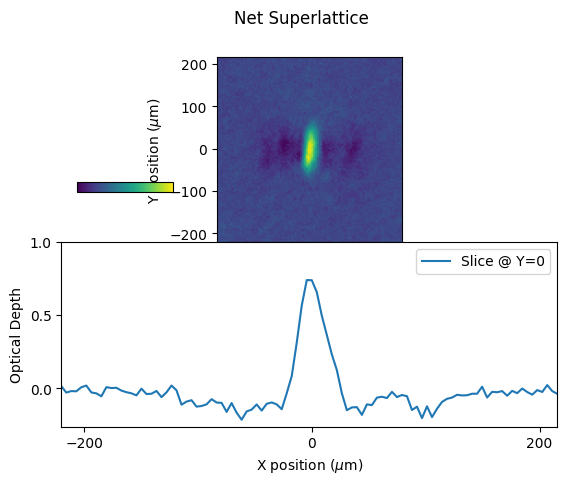

In [22]:
netpx = npx -sspx
netss = ns - sss
plotAveragedImages(netpx, netss, ssx, ssy, "Net Superlattice")

In [24]:
netpx.shape

(100, 100)

In [36]:
hbar = 1.055e-34
lamda = 780e-9
k = 2*np.pi/lamda
M = 87*1.6605e-27

E_R = hbar**2 * k**2/(2*M)
E_R /= 6.626e-34
E_R_l = E_R*20
E_R_l 

75451.15399190859

In [37]:
base_filename = "Data/SuperlatticeExpt_tof_big_rep_"
num_runs = 3

superlattice = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

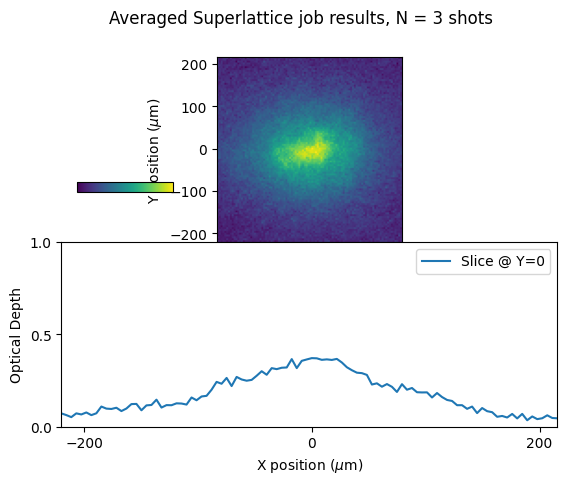

In [41]:
sspx, sss, ssx, ssy = averageMatterImages(superlattice, "TIME_OF_FLIGHT")
plotAveragedImages(sspx, sss, ssx, ssy, "Averaged Superlattice job results, N = 3 shots")